## Dataset

**MetroPT-3 Air Compressor Dataset**  
Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/791/metropt+3+dataset)

Download and extract the dataset into `data/raw/` before running this notebook:

In [70]:
import subprocess
import zipfile
import pathlib

data_raw = pathlib.Path("../data/raw")
data_raw.mkdir(parents=True, exist_ok=True)

zip_path = data_raw / "metropt3.zip"

# Download and extract the dataset from UCI Machine Learning Repository
# If the file already exists, skip the download and extraction steps
if zip_path.exists():
    print(f"{zip_path} already exists. Skipping download and extraction.")
else:  # Download
    subprocess.run([
        "wget",
        "-O", str(zip_path),
        "https://archive.ics.uci.edu/static/public/791/metropt+3+dataset.zip"
    ], check=True)

# Extract
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(data_raw)

print("Files in data/raw/:")
for f in sorted(data_raw.iterdir()):
    print(" ", f.name)

../data/raw/metropt3.zip already exists. Skipping download and extraction.
Files in data/raw/:
  Data Description_Metro.pdf
  MetroPT3(AirCompressor).csv
  MetroPT3(AirCompressor).parquet
  analogue_sensors_labeled.png
  metropt3.zip
  metropt_raw.parquet
  metropt_raw_labeled.parquet


## 1. Load & Check

In [71]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path("..")
raw_folder = root / "data" / "raw"

csv_files = list(raw_folder.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in data/raw/")

csv_path = csv_files[0]
print("Using file:", csv_path)

Using file: ../data/raw/MetroPT3(AirCompressor).csv


In [72]:
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End:  ", df["timestamp"].max())
df.head()
# # Min and max values for column tp2
# print("tp2 min:", df["tp2"].min())
# print("tp2 max:", df["tp2"].max())

# # Create a histogram of tp2 values
# plt.figure(figsize=(10, 6))
# plt.hist(df["tp2"], bins=50, color="blue", alpha=0.7)
# plt.title("Distribution of tp2 values")
# plt.xlabel("tp2")
# plt.ylabel("Frequency")
# plt.grid(True)
# plt.show()

Shape: (1516948, 17)
Start: 2020-02-01 00:00:00
End:   2020-09-01 03:59:50


,unnamed:_0,timestamp,tp2,tp3,h1,dv_pressure,reservoirs,oil_temperature,motor_current,comp,dv_eletric,towers,mpg,lps,pressure_switch,oil_level,caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [73]:
# Print the feature names and their data types
print("\nFeature names and data types:")
print(df.dtypes)

# The meaning of each feature is as follows:
# - `timestamp`: The date and time when the data was recorded.
# - `tp2` (bar) – the measure of the pressure at the inlet of the compressor.
# - `tp3` (bar) – the measure of the pressure on the compressor.
# - `H1` (bar) – the measure of the pressure generated due to pressure drop when the discharge of the cyclonic
# separator filter occurs.
# - `DV pressure` (bar) – the measure of the pressure drop generated when the towers discharge air dryers; a zero
# reading indicates that the compressor is operating under load.
# - `Reservoirs` (bar) – the measure of the downstream pressure of the reservoirs, which should be close to the pneumatic panel pressure (TP3).
# - `Motor Current` (A) – the measure of the current of one phase of the three-phase motor; it presents values close to 0A - when it turns off, 4A - when working offloaded, 7A - when working under load, and 9A - when it starts working.
# - `Oil Temperature` (ºC) – the measure of the oil temperature on the compressor.
# - `COMP` - the electrical signal of the air intake valve on the compressor; it is active when there is no air intake, indicating that the compressor is either turned off or operating in an offloaded state.
# - `DV electric` - the electrical signal that controls the compressor outlet valve; it is active when the compressor is functioning under load and inactive when the compressor is either off or operating in an offloaded state.
# - `TOWERS` - the electrical signal that defines the tower responsible for drying the air and the tower responsible for draining the humidity removed from the air; when not active, it indicates that tower one is functioning; when active, it indicates that tower two is in operation.
# - `MPG` - the electrical signal responsible for starting the compressor under load by activating the intake valve when the pressure in the air production unit (APU) falls below 8.2 bar; it activates the COMP sensor, which assumes the same behaviour as the MPG sensor.
# - `LPS` - the electrical signal that detects and activates when the pressure drops below 7 bars.
# - `Pressure Switch` - the electrical signal that detects the discharge in the air-drying towers.
# - `Oil Level` - the electrical signal that detects the oil level on the compressor; it is active when the oil is below the expected values.
# - `Caudal Impulse` - the electrical signal that counts the pulse outputs generated by the absolute amount of air flowing from the APU to the reservoir


Feature names and data types:
unnamed:_0                  int64
timestamp          datetime64[us]
tp2                       float64
tp3                       float64
h1                        float64
dv_pressure               float64
reservoirs                float64
oil_temperature           float64
motor_current             float64
comp                      float64
dv_eletric                float64
towers                    float64
mpg                       float64
lps                       float64
pressure_switch           float64
oil_level                 float64
caudal_impulses           float64
dtype: object


In [74]:
print("Missing values:")
print(df.isna().sum())

dt = df["timestamp"].diff().dropna().dt.total_seconds()
print("\nTime gap summary (seconds):")
print(dt.describe())
print("\nMost common gaps:")
print(dt.value_counts().head(10))

Missing values:
unnamed:_0         0
timestamp          0
tp2                0
tp3                0
h1                 0
dv_pressure        0
reservoirs         0
oil_temperature    0
motor_current      0
comp               0
dv_eletric         0
towers             0
mpg                0
lps                0
pressure_switch    0
oil_level          0
caudal_impulses    0
dtype: int64

Time gap summary (seconds):
count    1.516947e+06
mean     1.214122e+01
std      3.141073e+02
min      8.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.729180e+05
Name: timestamp, dtype: float64

Most common gaps:
timestamp
10.0    1337521
9.0      128277
12.0      38321
13.0       7988
11.0       4471
21.0         10
19.0          5
22.0          4
20.0          3
17.0          3
Name: count, dtype: int64


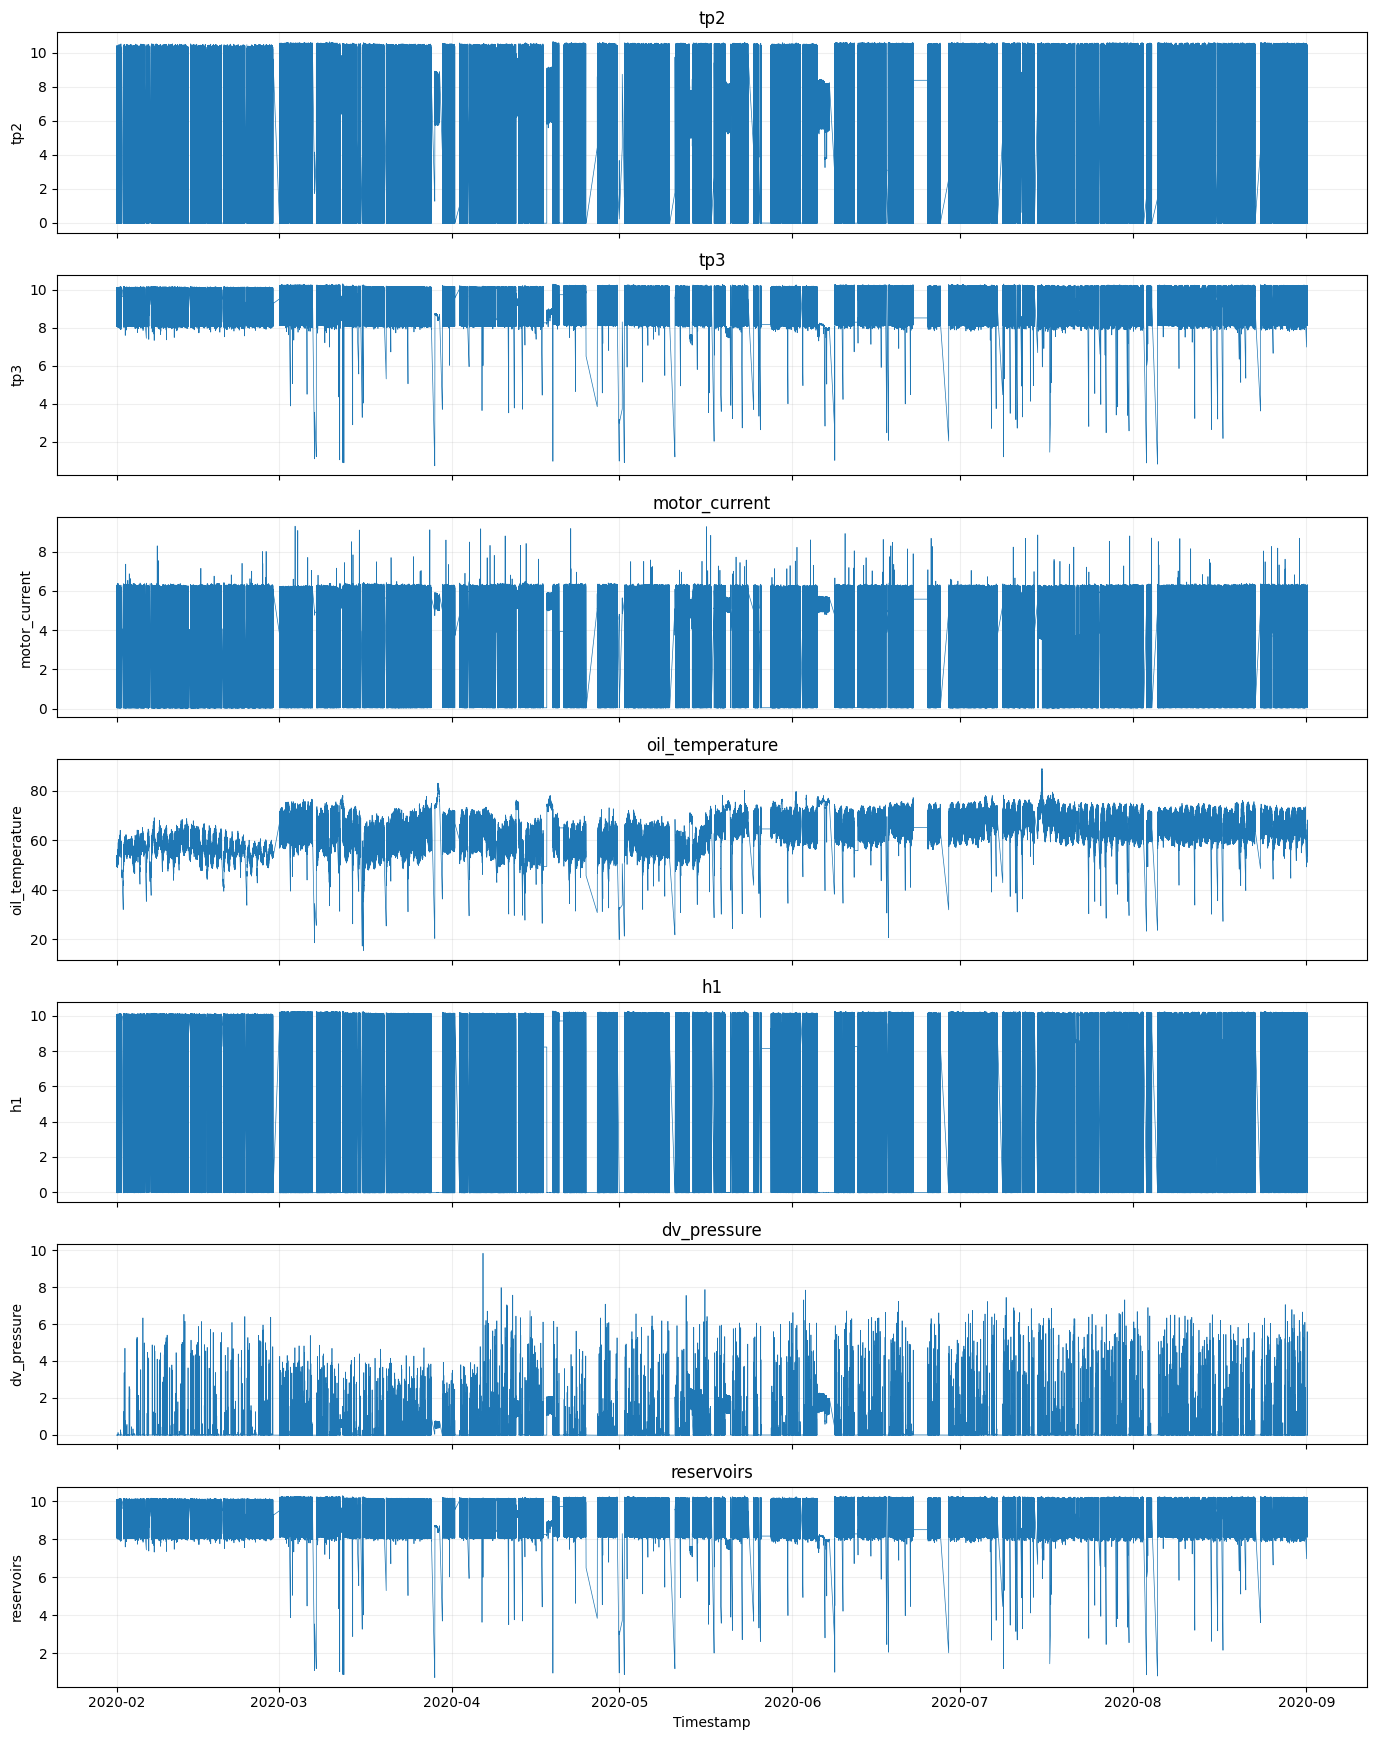

In [75]:
# Simple overview plot of key features
features_to_plot = ["tp2", "tp3", "motor_current",
                    "oil_temperature", "h1", "dv_pressure", "reservoirs"]
features_to_plot = [f for f in features_to_plot if f in df.columns]

fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(
    14, 2.5 * len(features_to_plot)), sharex=True)
if len(features_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, features_to_plot):
    ax.plot(df["timestamp"], df[col], linewidth=0.5)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

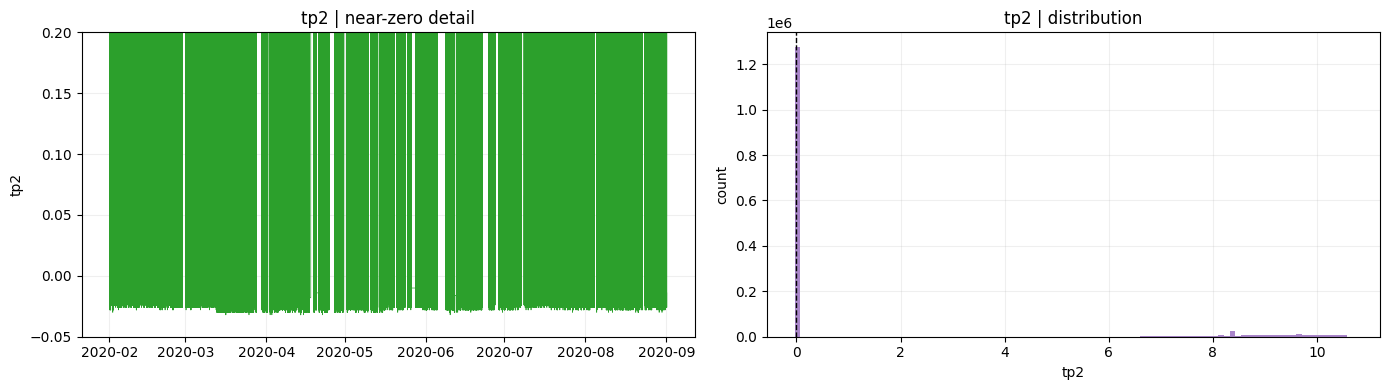

tp2 range: [-0.032, 10.676]
Values < 0.5: 84.2%


In [76]:
# Diagnostic: tp2 zoom and distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Near-zero zoom
axes[0].plot(df["timestamp"], df["tp2"], linewidth=0.5, color="tab:green")
axes[0].set_ylim(-0.05, 0.2)
axes[0].set_title("tp2 | near-zero detail")
axes[0].set_ylabel("tp2")
axes[0].grid(alpha=0.2)

# Distribution
axes[1].hist(df["tp2"], bins=100, color="tab:purple", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("tp2 | distribution")
axes[1].set_xlabel("tp2")
axes[1].set_ylabel("count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"tp2 range: [{df['tp2'].min():.3f}, {df['tp2'].max():.3f}]")
print(f"Values < 0.5: {(df['tp2'] < 0.5).mean()*100:.1f}%")

In [77]:
df.to_parquet(csv_path.with_suffix(".parquet"), index=False)
print("Saved parquet:", csv_path.with_suffix(".parquet"))

Saved parquet: ../data/raw/MetroPT3(AirCompressor).parquet


## 2. Label Failures & Plot

In [78]:
# These are the known failure windows in the dataset, which we will use to label the data for supervised learning.
failure_windows = [
    {"name": "failure_1", "start": "2020-04-18 00:00:00",
        "end": "2020-04-18 23:59:00"},
    {"name": "failure_2", "start": "2020-05-29 23:30:00",
        "end": "2020-05-30 06:00:00"},
    {"name": "failure_3", "start": "2020-06-05 10:00:00",
        "end": "2020-06-07 14:30:00"},
    {"name": "failure_4", "start": "2020-07-15 14:30:00",
        "end": "2020-07-15 19:00:00"},
]
print("\nFailure windows:")
for event in failure_windows:
    print(f"{event['name']}: {event['start']} to {event['end']}")

df["failure"] = 0
df["failure_name"] = "none"

for event in failure_windows:
    start = pd.Timestamp(event["start"])
    end = pd.Timestamp(event["end"])
    mask = (df["timestamp"] >= start) & (df["timestamp"] <= end)
    df.loc[mask, "failure"] = 1
    df.loc[mask, "failure_name"] = event["name"]

print("Failure rows:", df["failure"].sum())
df["failure"].value_counts()


Failure windows:
failure_1: 2020-04-18 00:00:00 to 2020-04-18 23:59:00
failure_2: 2020-05-29 23:30:00 to 2020-05-30 06:00:00
failure_3: 2020-06-05 10:00:00 to 2020-06-07 14:30:00
failure_4: 2020-07-15 14:30:00 to 2020-07-15 19:00:00
Failure rows: 29954


failure
0    1486994
1      29954
Name: count, dtype: int64

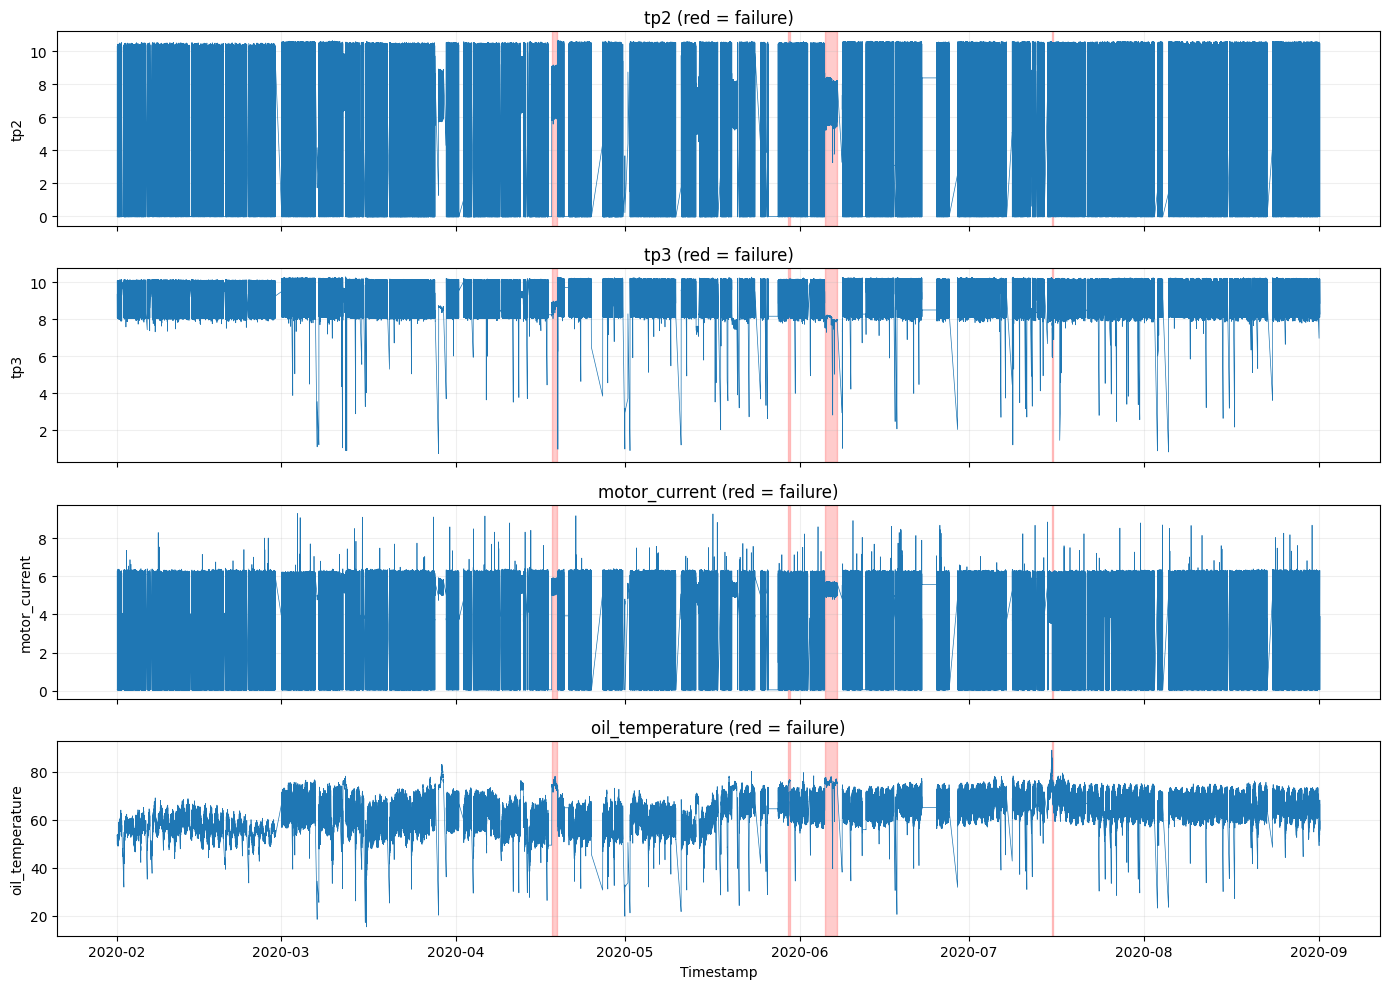

In [79]:
# Plot key features with failure windows highlighted
features = ["tp2", "tp3", "motor_current", "oil_temperature"]
features = [f for f in features if f in df.columns]

fig, axes = plt.subplots(len(features), 1, figsize=(
    14, 2.5 * len(features)), sharex=True)
if len(features) == 1:
    axes = [axes]

for ax, col in zip(axes, features):
    ax.plot(df["timestamp"], df[col], linewidth=0.5)
    # Shade failure windows
    for event in failure_windows:
        start = pd.Timestamp(event["start"])
        end = pd.Timestamp(event["end"])
        ax.axvspan(start, end, alpha=0.2, color="red")
    ax.set_title(f"{col} (red = failure)")
    ax.set_ylabel(col)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


Plotting around event: failure_1 (2020-04-18 00:00:00 to 2020-04-18 23:59:00)
Data points in window: 54258 | Window range: 2020-04-15 00:25:12 to 2020-04-21 19:41:35


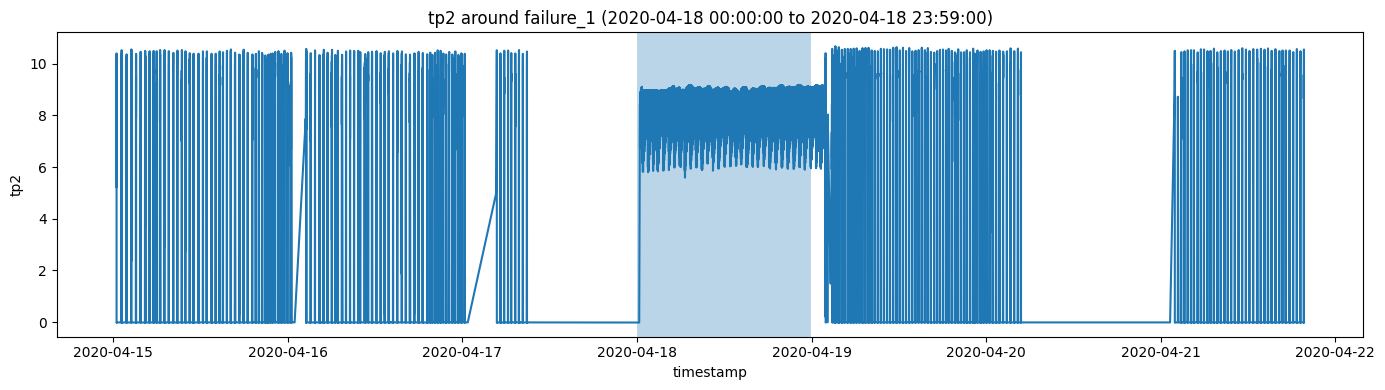

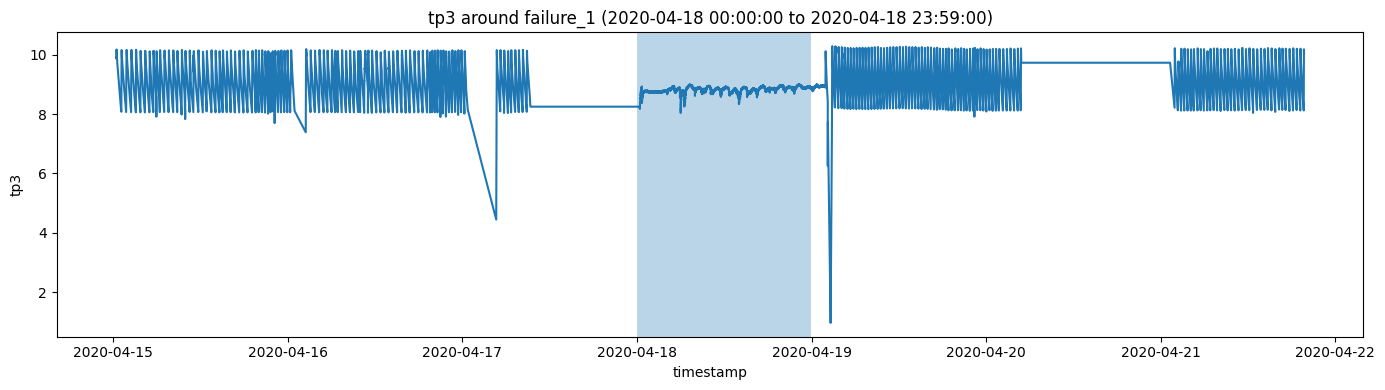

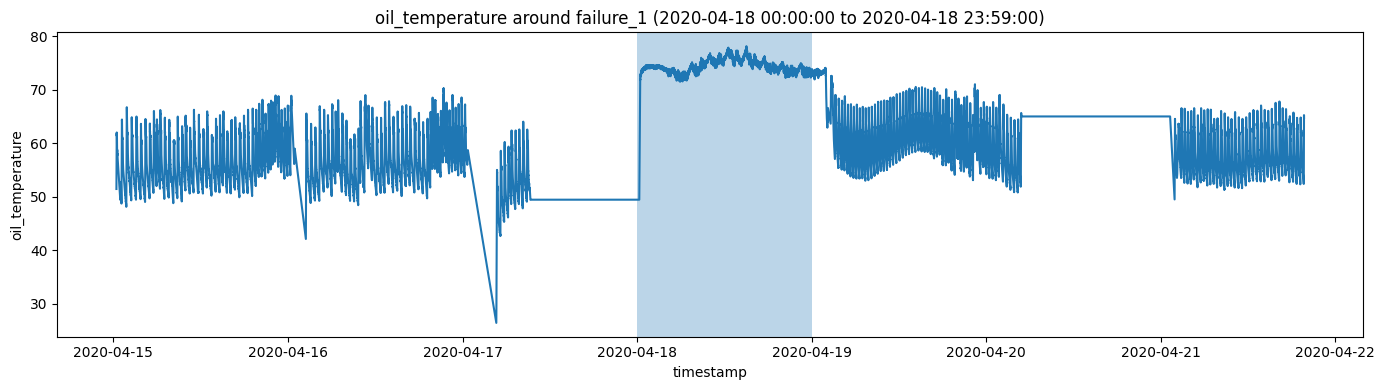

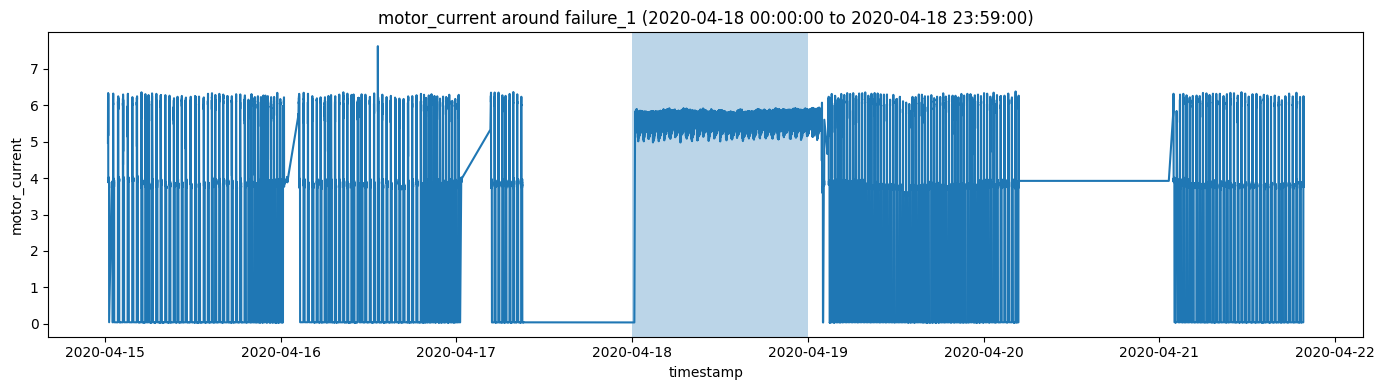

In [80]:
columns_to_plot = ["tp2", "tp3", "oil_temperature", "motor_current"]

event = failure_windows[0]
print(
    f"\nPlotting around event: {event['name']} ({event['start']} to {event['end']})")
start = pd.Timestamp(event["start"])
end = pd.Timestamp(event["end"])
# We will plot a window of data around the failure event, including 3 days before and after the event.
window_start = start - pd.Timedelta(days=3)
window_end = end + pd.Timedelta(days=3)

small = df[(df["timestamp"] >= window_start) & (df["timestamp"] <= window_end)]
print(
    f"Data points in window: {len(small)} | Window range: {small['timestamp'].min()} to {small['timestamp'].max()}")

for col in columns_to_plot:
    if col not in df.columns:
        print(f"Skipping {col}")
        continue
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(small["timestamp"], small[col])
    ax.axvspan(start, end, alpha=0.3)
    ax.set_title(
        f"{col} around {event['name']} ({event['start']} to {event['end']})")
    ax.set_xlabel("timestamp")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

In [81]:
# Sort the data by timestamp to ensure correct order
df = df.sort_values("timestamp").reset_index(drop=True)

# -----------------------------
# 1) choose target column
# -----------------------------
# this is the sensor we want to predict one step ahead

preferred_target_columns = [
    "tp2",
    "tp3",
    "oil_temperature",
    "motor_current",
]

target_col = None
for col in preferred_target_columns:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(
        "Could not find a target column. Check your column names.")

print("Target column:", target_col)

# -----------------------------
# 2) choose input sensor columns
# -----------------------------
# these are the signals we use to build features

preferred_input_columns = [
    "tp2",
    "tp3",
    "oil_temperature",
    "motor_current",
    "dv_pressure",
    "reservoirs",
]

input_cols = [col for col in preferred_input_columns if col in df.columns]

if len(input_cols) == 0:
    raise ValueError(
        "No expected sensor columns found. Check your column names.")

print("Input columns used:")
print(input_cols)

# -----------------------------
# 3) create future target
# -----------------------------
# predict the next value of the target column
# y(t) = target at next time step

df["target_next"] = df[target_col].shift(-1)


# -----------------------------
# 4) create simple time features
# -----------------------------
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
# print(df.head())
# The last row will have NaN in target_next because there is no future value for the last timestamp.
# print(df.tail())


# -----------------------------
# 5) create lag and rolling features
# -----------------------------
# IMPORTANT:
# we only use current and past information
# never future information

for col in input_cols:
    # lag features
    df[f"{col}_lag_1"] = df[col].shift(1)
    df[f"{col}_lag_5"] = df[col].shift(5)
    df[f"{col}_lag_15"] = df[col].shift(15)

    # simple difference
    df[f"{col}_diff_1"] = df[col] - df[col].shift(1)

    # rolling features using only past values
    past = df[col].shift(1)
    df[f"{col}_roll_mean_5"] = past.rolling(5).mean()
    df[f"{col}_roll_std_5"] = past.rolling(5).std()
    df[f"{col}_roll_mean_15"] = past.rolling(15).mean()
    df[f"{col}_roll_std_15"] = past.rolling(15).std()


# print(df.head())

# -----------------------------
# 6) keep useful columns
# -----------------------------
# keep timestamp and failure for later evaluation
keep_cols = ["timestamp", "failure", "failure_name",
             target_col, "target_next", "hour", "dayofweek"]

feature_cols = []
for col in df.columns:
    if (
        "_lag_" in col
        or "_diff_" in col
        or "_roll_" in col
    ):
        feature_cols.append(col)

# print(df.head())

final_cols = []
for col in keep_cols + feature_cols:
    if col in df.columns:
        final_cols.append(col)

features_df = df[final_cols].copy()

# -----------------------------
# 7) drop rows with NaN
# -----------------------------
# first rows have NaN because lag/rolling features need history
# last row has NaN because target_next uses shift(-1)

before = len(features_df)
features_df = features_df.dropna().reset_index(drop=True)
after = len(features_df)

print()
print("Rows before dropna:", before)
print("Rows after dropna: ", after)
print("Dropped rows:      ", before - after)

# # -----------------------------
# # 8) save output
# # -----------------------------

precessed_folder = root / "data" / "processed"
# Path("data/processed").mkdir(parents=True, exist_ok=True)
out_path = precessed_folder / "metropt_features.parquet"
features_df.to_parquet(out_path, index=False)

print()
print("Saved feature file:", out_path)
print()
print("Feature columns:")
print(features_df.columns.tolist())
print()
print("First rows:")
print(features_df.head())

Target column: tp2
Input columns used:
['tp2', 'tp3', 'oil_temperature', 'motor_current', 'dv_pressure', 'reservoirs']

Rows before dropna: 1516948
Rows after dropna:  1516932
Dropped rows:       16

Saved feature file: ../data/processed/metropt_features.parquet

Feature columns:
['timestamp', 'failure', 'failure_name', 'tp2', 'target_next', 'hour', 'dayofweek', 'tp2_lag_1', 'tp2_lag_5', 'tp2_lag_15', 'tp2_diff_1', 'tp2_roll_mean_5', 'tp2_roll_std_5', 'tp2_roll_mean_15', 'tp2_roll_std_15', 'tp3_lag_1', 'tp3_lag_5', 'tp3_lag_15', 'tp3_diff_1', 'tp3_roll_mean_5', 'tp3_roll_std_5', 'tp3_roll_mean_15', 'tp3_roll_std_15', 'oil_temperature_lag_1', 'oil_temperature_lag_5', 'oil_temperature_lag_15', 'oil_temperature_diff_1', 'oil_temperature_roll_mean_5', 'oil_temperature_roll_std_5', 'oil_temperature_roll_mean_15', 'oil_temperature_roll_std_15', 'motor_current_lag_1', 'motor_current_lag_5', 'motor_current_lag_15', 'motor_current_diff_1', 'motor_current_roll_mean_5', 'motor_current_roll_std_5'